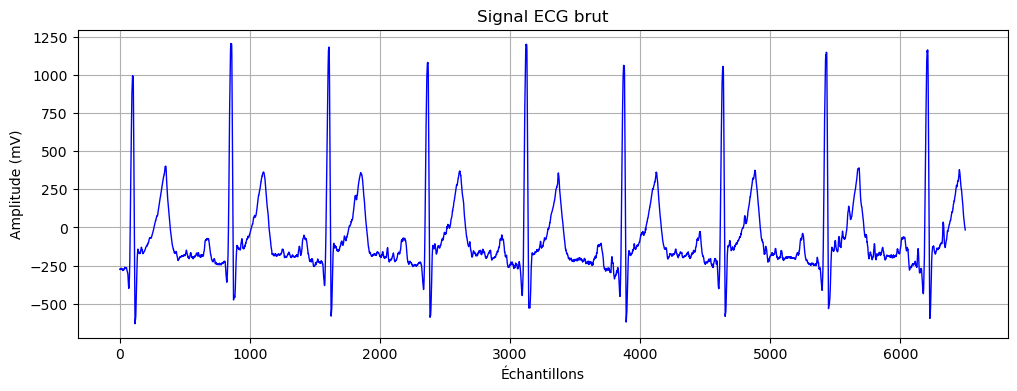

In [7]:
import pandas as pd

# Guillemet de fermeture ajoutée après le nom du fichier
df = pd.read_csv(
    r"C:\Users\damie\OneDrive\Documents\Fac\Master 1\IEAP\Python-R-Git\Series01\Series01-python\data\ECGu.txt",
    sep="\t",
)
df.head()
import numpy as np
import matplotlib.pyplot as plt

# Création du graphique
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:, 0], color="blue", linewidth=1)

# Titre et nom des axes
plt.title("Signal ECG brut")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude (mV)")
plt.grid(True)

# Affichage
plt.show()

Le tracé montre un signal périodique avec des pics clairs (complexes QRS) sans valeurs aberrantes. L'affichage est donc cohérent avec un signal ECG brut.

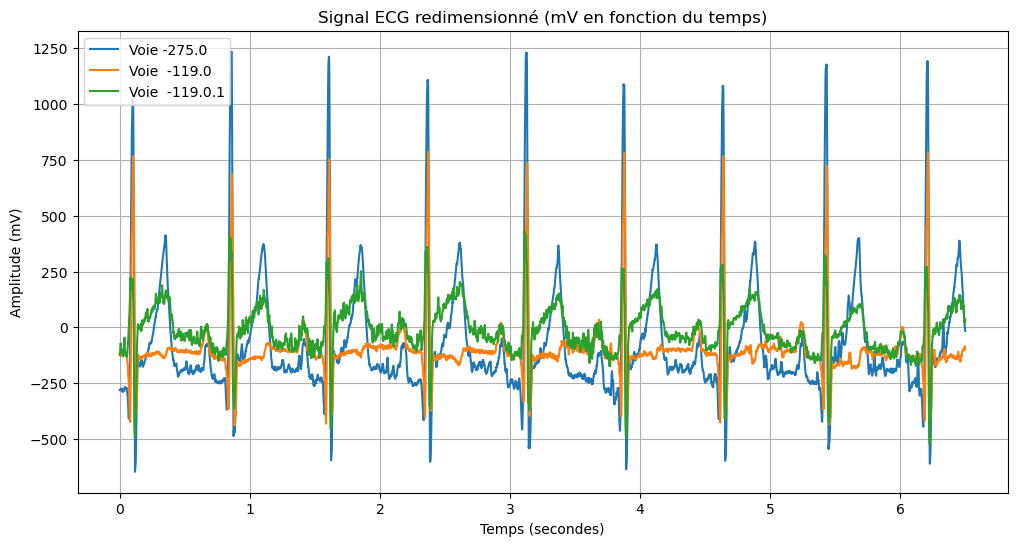

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- CORRECTION ICI ---
# 1. Sélectionne uniquement les 3 premières colonnes (on ignore la colonne vide)
# Et nettoie uniquement ces colonnes.
df_clean = df.iloc[:, :3].apply(pd.to_numeric, errors="coerce").dropna()
# --- FIN CORRECTION ---

# Le reste du code reste le même :
# 2. Conversion en mV (Gain de 1024 µV par unité = 1.024 mV)
df_mv = df_clean * (1024 / 1000)

# 3. Conversion du temps en secondes (1 échantillon = 0.001 s à 1000 Hz)
frequence_ech = 1000  # Hz
temps_sec = np.arange(len(df_mv)) / frequence_ech

# 4. Tracé des signaux
plt.figure(figsize=(12, 6))

for col in df_mv.columns:
    plt.plot(temps_sec, df_mv[col], label=f"Voie {col}")

plt.title("Signal ECG redimensionné (mV en fonction du temps)")
plt.xlabel("Temps (secondes)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def load_ecg_data(file_path: str) -> pd.DataFrame:
    """Charge et nettoie le fichier de données ECG texte."""
    raw_df = pd.read_csv(file_path, sep="\t")
    # Sélection des 3 canaux et nettoyage
    clean_df = raw_df.iloc[:, :3].apply(pd.to_numeric, errors="coerce").dropna()
    clean_df.columns = ["Lead_I", "Lead_II", "Lead_III"]
    return clean_df


def convert_raw_to_mv(
    ecg_df: pd.DataFrame, gain_uv_per_unit: float = 1024.0
) -> pd.DataFrame:
    """Convertit le signal ECG brut en millivolts (mV)."""
    return ecg_df * (gain_uv_per_unit / 1000.0)


def generate_time_vector(
    num_samples: int, sampling_rate_hz: float = 1000.0
) -> np.ndarray:
    """Génère le vecteur temporel en secondes basé sur la fréquence d'échantillonnage."""
    return np.arange(num_samples) / sampling_rate_hz


def plot_ecg_leads(
    time_sec: np.ndarray, ecg_mv_df: pd.DataFrame, title: str
) -> None:
    """Affiche les 3 dérivations ECG sur un graphique unique."""
    plt.figure(figsize=(12, 5))
    for lead in ecg_mv_df.columns:
        plt.plot(time_sec, ecg_mv_df[lead], label=lead, linewidth=1)

    plt.title(title)
    plt.xlabel("Temps (secondes)")
    plt.ylabel("Amplitude (mV)")
    plt.legend()
    plt.grid(True)
    plt.show()

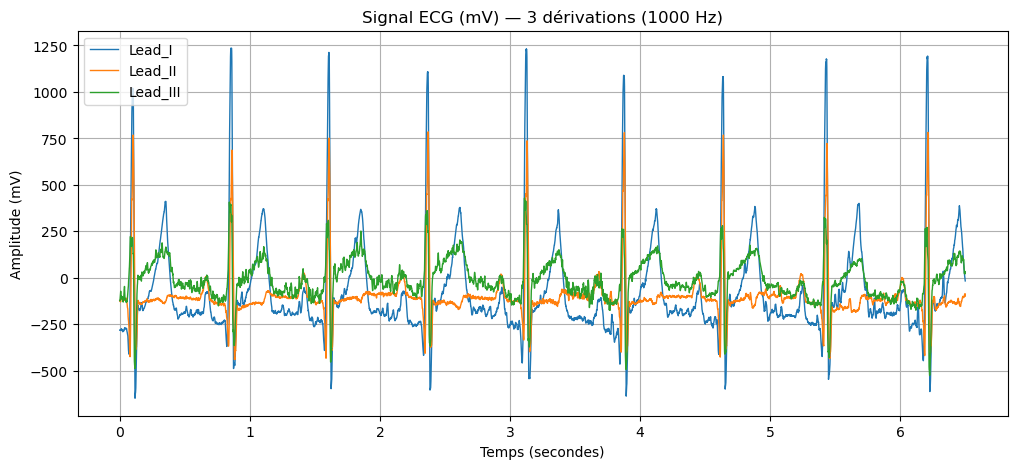

In [13]:
# 1. Chargement et prétraitement
file_path = r"C:\Users\damie\OneDrive\Documents\Fac\Master 1\IEAP\Python-R-Git\Series01\Series01-python\data\ECGu.txt"
ecg_raw = load_ecg_data(file_path)

# 2. Conversion des unités
ecg_mv = convert_raw_to_mv(ecg_raw, gain_uv_per_unit=1024.0)
time_vector = generate_time_vector(
    num_samples=len(ecg_mv), sampling_rate_hz=1000.0
)

# 3. Tracé final
plot_ecg_leads(
    time_vector, ecg_mv, title="Signal ECG (mV) — 3 dérivations (1000 Hz)"
)